# 03 — Model Selection and Evaluation

This notebook performs a reproducible **educational benchmark** using the deterministic preparation handoff created by notebook 02. Hyperparameter tuning is restricted to `train`, external comparison and educational threshold analysis are restricted to `validation`, and `test` remains sealed for notebook 04.

## 1. Model-Selection Context

The goal is to compare four required probability-classification families against a non-eligible Dummy baseline. Average Precision is the primary metric because churn is the positive class and class imbalance makes accuracy insufficient for selection.

This snapshot benchmark does **not** establish future-customer performance, temporal validity, feature availability at inference time, causal effects, production readiness, or an operational retention threshold.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import sys
import warnings
from pathlib import Path


def _bootstrap_project_root() -> Path:
    candidates = []
    configured = os.getenv('DATASET_STUDY_ROOT')
    if configured:
        candidates.append(Path(configured).expanduser())
    candidates.extend([Path.cwd(), *Path.cwd().parents])
    for candidate in candidates:
        resolved = candidate.resolve()
        if (resolved / 'scripts' / 'download_data.py').is_file():
            return resolved
    raise RuntimeError(
        "Dataset study project root not found; expected scripts/download_data.py."
    )


PROJECT_BOOTSTRAP_ROOT = _bootstrap_project_root()
if str(PROJECT_BOOTSTRAP_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_BOOTSTRAP_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from scripts.project_context import get_project_context
from scripts.prepare_data import load_and_validate_preparation_handoff
from scripts.select_models import (
    ARTIFACT_FILENAMES,
    analyze_thresholds,
    build_candidate_pipeline,
    build_candidate_results,
    build_cross_validation,
    build_model_selection_handoff,
    build_model_selection_manifest,
    build_scoring_contract,
    build_threshold_analysis,
    build_validation_evidence,
    describe_cv_folds,
    evaluate_candidates_on_validation,
    evaluate_probability_classifier,
    load_and_validate_model_selection_handoff,
    report_unknown_categories,
    run_model_search,
    runtime_versions,
    select_candidate_model,
    semantic_fingerprint_json,
    sha256_file,
    summarize_search_results,
    validate_candidate_model_specs,
    validate_feature_partition_roles,
    validate_model_selection_contract,
    write_model_selection_artifacts,
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

## 2. Independent Project and Preparation-Handoff Loading

Project discovery is independent of notebook 02 kernel state. Only project-relative paths are displayed.

In [2]:
context = get_project_context()
PROJECT_ROOT = context.root
DATASET_SLUG = 'telco-customer-churn'
PREPARATION_ROOT = Path('artifacts/preparation') / DATASET_SLUG
MODEL_SELECTION_ROOT = Path('artifacts/model-selection') / DATASET_SLUG

PREPARATION_PATHS = {
    'preparation_manifest': PREPARATION_ROOT / 'preparation-manifest.json',
    'feature_manifest': PREPARATION_ROOT / 'feature-manifest.json',
    'split_manifest': PREPARATION_ROOT / 'split-manifest.json',
    'quality_evidence': PREPARATION_ROOT / 'quality-evidence.json',
}

for name, relative_path in PREPARATION_PATHS.items():
    context.require_file(relative_path)

print(f'Project: {context.name}')
print('Preparation artifacts:')
for name, relative_path in PREPARATION_PATHS.items():
    print(f'  {name}: {relative_path.as_posix()}')

Project: dataset-study-telco-customer-churn
Preparation artifacts:
  preparation_manifest: artifacts/preparation/telco-customer-churn/preparation-manifest.json
  feature_manifest: artifacts/preparation/telco-customer-churn/feature-manifest.json
  split_manifest: artifacts/preparation/telco-customer-churn/split-manifest.json
  quality_evidence: artifacts/preparation/telco-customer-churn/quality-evidence.json


## 3. Preparation-Handoff Integrity Gate

The public preparation API validates the persisted prepared dataset, all three partition files, manifest schemas, hashes, fingerprints, membership, coverage, disjointness, class presence, and readiness. The returned object necessarily reads `test` for structural integrity; no test DataFrame is assigned to a model-selection variable, and the handoff object is deleted immediately after copying only `train`, `validation`, and manifest metadata.

In [3]:
preparation_handoff = load_and_validate_preparation_handoff(
    project_root=PROJECT_ROOT,
    preparation_manifest_path=PREPARATION_PATHS['preparation_manifest'],
    feature_manifest_path=PREPARATION_PATHS['feature_manifest'],
    split_manifest_path=PREPARATION_PATHS['split_manifest'],
    quality_evidence_path=PREPARATION_PATHS['quality_evidence'],
)

train_df = preparation_handoff.train
validation_df = preparation_handoff.validation
preparation_manifests = preparation_handoff.manifests

test_integrity_reference = {
    'path': preparation_manifests['split_manifest']['partition_paths']['test'],
    'sha256': preparation_manifests['split_manifest']['partition_sha256']['test'],
    'row_count': preparation_manifests['split_manifest']['row_counts']['test'],
    'class_counts': preparation_manifests['split_manifest']['class_counts']['test'],
    'policy': preparation_manifests['split_manifest']['test_holdout_policy'],
}

del preparation_handoff

assert preparation_manifests['preparation_manifest']['readiness']['educational_model_selection_ready'] is True
assert preparation_manifests['split_manifest']['isolation_checks']['test_holdout_isolated'] is True
assert preparation_manifests['split_manifest']['operational_modeling_ready'] is False
assert preparation_manifests['split_manifest']['operational_validity'] == 'unconfirmed'
assert preparation_manifests['split_manifest']['temporal_contract_status'] == 'unresolved'
assert preparation_manifests['split_manifest']['feature_inference_availability'] == 'unconfirmed'

print('Preparation handoff integrity gate: PASSED')
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {validation_df.shape}")
print('Test partition: structurally validated and sealed (no evaluation variable created).')
print(json.dumps(test_integrity_reference, indent=2, sort_keys=True))

Preparation handoff integrity gate: PASSED
Train shape: (4930, 21)
Validation shape: (1056, 21)
Test partition: structurally validated and sealed (no evaluation variable created).
{
  "class_counts": {
    "No": 776,
    "Yes": 281
  },
  "path": "data/processed/telco-customer-churn/splits/stratified-random-snapshot-seed-42/test.csv",
  "policy": "The test partition is isolated and must not be used for feature, preprocessing, model, hyperparameter, threshold, or metric selection.",
  "row_count": 1057,
  "sha256": "f6c99adfe3854643ca70ec4910c58645ba39fe1ec75b54f0ab0807c0fb2662fb"
}


## 4. Feature, Target, and Partition Roles

`customerID` is lineage only. `Churn` is the target. Target encoding is in memory, the declared feature order is preserved, `SeniorCitizen` remains categorical, and no prepared CSV is modified.

In [4]:
feature_manifest = preparation_manifests['feature_manifest']
TARGET_COLUMN = feature_manifest['target_column']
TARGET_CLASSES = tuple(feature_manifest['target_classes'])
POSITIVE_TARGET_CLASS = feature_manifest['positive_target_class']
TARGET_ENCODING = dict(feature_manifest['target_encoding_contract'])
IDENTIFIER_COLUMNS = tuple(feature_manifest['identifier_columns'])
NUMERICAL_FEATURES = tuple(feature_manifest['numerical_features'])
CATEGORICAL_FEATURES = tuple(feature_manifest['categorical_features'])
FEATURE_COLUMNS = tuple(feature_manifest['feature_columns'])

roles = validate_feature_partition_roles(
    train=train_df,
    validation=validation_df,
    feature_columns=FEATURE_COLUMNS,
    identifier_columns=IDENTIFIER_COLUMNS,
    target_column=TARGET_COLUMN,
    target_classes=TARGET_CLASSES,
    positive_class=POSITIVE_TARGET_CLASS,
    target_encoding=TARGET_ENCODING,
)
X_train = roles.x_train
y_train = roles.y_train
X_validation = roles.x_validation
y_validation = roles.y_validation
del roles

assert list(X_train.columns) == list(FEATURE_COLUMNS)
assert list(X_validation.columns) == list(FEATURE_COLUMNS)
assert not set(IDENTIFIER_COLUMNS).intersection(X_train.columns)
assert TARGET_COLUMN not in X_train.columns
assert 'SeniorCitizen' in CATEGORICAL_FEATURES
assert pd.api.types.is_numeric_dtype(train_df['TotalCharges'])

role_summary = pd.DataFrame({
    'role': ['identifier', 'numerical', 'categorical', 'target', 'positive class'],
    'columns_or_value': [
        ', '.join(IDENTIFIER_COLUMNS),
        ', '.join(NUMERICAL_FEATURES),
        ', '.join(CATEGORICAL_FEATURES),
        TARGET_COLUMN,
        POSITIVE_TARGET_CLASS,
    ],
})
display(role_summary)

,role,columns_or_value
0,identifier,customerID
1,numerical,"tenure, MonthlyCharges, TotalCharges"
2,categorical,"gender, SeniorCitizen, Partner, Dependents, Ph..."
3,target,Churn
4,positive class,Yes


## 5. Educational Evaluation Contract

The contract is declared before model execution. False negatives are the priority error, but the dataset lacks the cost, campaign-capacity, intervention-effectiveness, and customer-value inputs required for an operational threshold.

In [5]:
RANDOM_SEED = 42
SEARCH_N_JOBS = 4
ESTIMATOR_N_JOBS = 1
DUMMY_AVERAGE_PRECISION_MARGIN = 0.01
PRACTICAL_TIE_TOLERANCE = 0.01
EDUCATIONAL_RECALL_TARGET = 0.80
DEFAULT_THRESHOLD = 0.50

MODEL_SELECTION_CONTRACT = validate_model_selection_contract({
    'evaluation_mode': 'stratified_random_snapshot',
    'purpose': 'educational_benchmark',
    'primary_metric': 'average_precision',
    'refit_metric': 'average_precision',
    'cv': {
        'strategy': 'StratifiedKFold',
        'n_splits': 5,
        'shuffle': True,
        'random_state': RANDOM_SEED,
    },
    'dummy_average_precision_margin': DUMMY_AVERAGE_PRECISION_MARGIN,
    'practical_tie_tolerance': PRACTICAL_TIE_TOLERANCE,
    'positive_class': POSITIVE_TARGET_CLASS,
    'priority_error': 'false_negative',
    'false_negative_cost': 'unknown',
    'false_positive_cost': 'unknown',
    'business_cost_ratio': 'unavailable',
    'educational_recall_target': EDUCATIONAL_RECALL_TARGET,
    'operational_recall_target': 'unresolved',
    'threshold_strategy': 'maximize_precision_subject_to_minimum_recall',
    'supporting_threshold_metric': 'f2',
    'threshold_selection_partition': 'validation',
    'test_partition_sealed': True,
    'operational_validity': 'unconfirmed',
    'operational_threshold': 'unresolved',
})

display(pd.Series(MODEL_SELECTION_CONTRACT, name='value').to_frame())

,value
evaluation_mode,stratified_random_snapshot
purpose,educational_benchmark
primary_metric,average_precision
refit_metric,average_precision
cv,"{'strategy': 'StratifiedKFold', 'n_splits': 5,..."
dummy_average_precision_margin,0.01
practical_tie_tolerance,0.01
positive_class,Yes
priority_error,false_negative
false_negative_cost,unknown


## 6. Candidate Models and Dummy Baseline

The Dummy baseline establishes a non-eligible floor. Exactly four candidate families are eligible for selection.

In [6]:
BASELINE_SPEC = {
    'model_id': 'dummy_prior',
    'family': 'DummyClassifier',
    'estimator': DummyClassifier(strategy='prior'),
    'eligible': False,
}

CANDIDATE_SPECS = [
    {
        'model_id': 'logistic_regression',
        'family': 'LogisticRegression',
        'estimator': LogisticRegression(
            solver='liblinear',
            max_iter=2000,
            random_state=RANDOM_SEED,
        ),
        'scale_numerical': True,
        'search_strategy': 'GridSearchCV',
        'search_space': {
            'model__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
            'model__penalty': ['l1', 'l2'],
            'model__class_weight': [None, 'balanced'],
        },
        'candidate_count': 24,
        'random_state': RANDOM_SEED,
        'numerical_features': NUMERICAL_FEATURES,
        'categorical_features': CATEGORICAL_FEATURES,
    },
    {
        'model_id': 'decision_tree',
        'family': 'DecisionTreeClassifier',
        'estimator': DecisionTreeClassifier(random_state=RANDOM_SEED),
        'scale_numerical': False,
        'search_strategy': 'GridSearchCV',
        'search_space': {
            'model__criterion': ['gini', 'entropy'],
            'model__max_depth': [3, 5, 8, None],
            'model__min_samples_leaf': [1, 10, 30],
            'model__class_weight': [None, 'balanced'],
        },
        'candidate_count': 48,
        'random_state': RANDOM_SEED,
        'numerical_features': NUMERICAL_FEATURES,
        'categorical_features': CATEGORICAL_FEATURES,
    },
    {
        'model_id': 'random_forest',
        'family': 'RandomForestClassifier',
        'estimator': RandomForestClassifier(
            random_state=RANDOM_SEED,
            n_jobs=ESTIMATOR_N_JOBS,
        ),
        'scale_numerical': False,
        'search_strategy': 'RandomizedSearchCV',
        'search_space': {
            'model__n_estimators': [300, 500, 800],
            'model__max_depth': [None, 8, 12, 20],
            'model__min_samples_split': [2, 10, 20],
            'model__min_samples_leaf': [1, 2, 5, 10],
            'model__max_features': ['sqrt', 0.5, None],
            'model__class_weight': [None, 'balanced', 'balanced_subsample'],
        },
        'n_iter': 40,
        'random_state': RANDOM_SEED,
        'numerical_features': NUMERICAL_FEATURES,
        'categorical_features': CATEGORICAL_FEATURES,
    },
    {
        'model_id': 'hist_gradient_boosting',
        'family': 'HistGradientBoostingClassifier',
        'estimator': HistGradientBoostingClassifier(random_state=RANDOM_SEED),
        'scale_numerical': False,
        'search_strategy': 'RandomizedSearchCV',
        'search_space': {
            'model__learning_rate': [0.03, 0.05, 0.1, 0.2],
            'model__max_iter': [100, 200, 400],
            'model__max_leaf_nodes': [7, 15, 31, 63],
            'model__max_depth': [None, 3, 5, 8],
            'model__min_samples_leaf': [10, 20, 40],
            'model__l2_regularization': [0.0, 0.01, 0.1, 1.0, 10.0],
        },
        'n_iter': 40,
        'random_state': RANDOM_SEED,
        'numerical_features': NUMERICAL_FEATURES,
        'categorical_features': CATEGORICAL_FEATURES,
    },
]

REQUIRED_FAMILY_SEARCH_STRATEGIES = {
    'LogisticRegression': 'GridSearchCV',
    'DecisionTreeClassifier': 'GridSearchCV',
    'RandomForestClassifier': 'RandomizedSearchCV',
    'HistGradientBoostingClassifier': 'RandomizedSearchCV',
}

BASELINE_SPEC, CANDIDATE_SPECS = validate_candidate_model_specs(
    baseline_spec=BASELINE_SPEC,
    candidate_specs=CANDIDATE_SPECS,
    required_family_search_strategies=REQUIRED_FAMILY_SEARCH_STRATEGIES,
    expected_candidate_count=4,
)

model_inventory = pd.DataFrame([
    {'model_id': BASELINE_SPEC['model_id'], 'family': BASELINE_SPEC['family'], 'strategy': 'single validation evaluation', 'candidates': 1, 'eligible': False},
    *[
        {
            'model_id': spec['model_id'],
            'family': spec['family'],
            'strategy': spec['search_strategy'],
            'candidates': spec.get('candidate_count', spec.get('n_iter')),
            'eligible': True,
        }
        for spec in CANDIDATE_SPECS
    ],
])
display(model_inventory)

,model_id,family,strategy,candidates,eligible
0,dummy_prior,DummyClassifier,single validation evaluation,1,False
1,logistic_regression,LogisticRegression,GridSearchCV,24,True
2,decision_tree,DecisionTreeClassifier,GridSearchCV,48,True
3,random_forest,RandomForestClassifier,RandomizedSearchCV,40,True
4,hist_gradient_boosting,HistGradientBoostingClassifier,RandomizedSearchCV,40,True


## 7. Fold-Safe Preprocessing Pipelines

One-hot encoding is fitted inside each training fold with unknown categories ignored and reported. Numerical scaling is applied only to Logistic Regression and remains inside its pipeline.

In [7]:
BASELINE_PIPELINE = build_candidate_pipeline(
    estimator=BASELINE_SPEC['estimator'],
    numerical_features=NUMERICAL_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    scale_numerical=False,
)

CANDIDATE_PIPELINES = {
    spec['model_id']: build_candidate_pipeline(
        estimator=spec['estimator'],
        numerical_features=NUMERICAL_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
        scale_numerical=spec['scale_numerical'],
    )
    for spec in CANDIDATE_SPECS
}

pipeline_contract = pd.DataFrame([
    {
        'model_id': spec['model_id'],
        'categorical': 'OneHotEncoder(handle_unknown=ignore, drop=None)',
        'numerical': 'StandardScaler' if spec['scale_numerical'] else 'passthrough',
        'fit_scope': 'inside training fold',
    }
    for spec in CANDIDATE_SPECS
])
display(pipeline_contract)

,model_id,categorical,numerical,fit_scope
0,logistic_regression,"OneHotEncoder(handle_unknown=ignore, drop=None)",StandardScaler,inside training fold
1,decision_tree,"OneHotEncoder(handle_unknown=ignore, drop=None)",passthrough,inside training fold
2,random_forest,"OneHotEncoder(handle_unknown=ignore, drop=None)",passthrough,inside training fold
3,hist_gradient_boosting,"OneHotEncoder(handle_unknown=ignore, drop=None)",passthrough,inside training fold


## 8. Cross-Validation and Scoring Contract

Five-fold stratified shuffled CV uses only `train`. Multiple scorers are recorded, but searches refit exclusively by Average Precision. Search-level parallelism is limited to two jobs; estimator-level forest parallelism is one job to avoid oversubscription.

In [8]:
SCORING = build_scoring_contract(positive_label=1)
CV = build_cross_validation(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
CV_FOLD_DISTRIBUTIONS = describe_cv_folds(cv=CV, x=X_train, y=y_train)

SCORING_METADATA = {
    'primary_metric': 'average_precision',
    'refit_metric': 'average_precision',
    'secondary_metrics': [
        'roc_auc', 'precision', 'recall', 'f1', 'f2',
        'balanced_accuracy', 'log_loss', 'brier_score', 'accuracy_context_only',
    ],
    'positive_encoded_label': 1,
    'zero_division': 0,
    'loss_orientation': 'human_lower_is_better',
}

print(f'CV: 5 folds, shuffled, seed={RANDOM_SEED}')
print(f'Search n_jobs: {SEARCH_N_JOBS}; estimator n_jobs: {ESTIMATOR_N_JOBS}')
display(pd.DataFrame(CV_FOLD_DISTRIBUTIONS))

CV: 5 folds, shuffled, seed=42
Search n_jobs: 4; estimator n_jobs: 1


,fold,train_rows,validation_rows,train_class_counts,validation_class_counts
0,1,3944,986,"{'0': 2898, '1': 1046}","{'0': 724, '1': 262}"
1,2,3944,986,"{'0': 2898, '1': 1046}","{'0': 724, '1': 262}"
2,3,3944,986,"{'0': 2898, '1': 1046}","{'0': 724, '1': 262}"
3,4,3944,986,"{'0': 2897, '1': 1047}","{'0': 725, '1': 261}"
4,5,3944,986,"{'0': 2897, '1': 1047}","{'0': 725, '1': 261}"


## 9. Hyperparameter Search Spaces

The complete declared spaces are fixed before validation evaluation. Grid searches enumerate 24 Logistic Regression and 48 Decision Tree combinations. Randomized searches sample 40 Random Forest and 40 HistGradientBoosting combinations with seed 42.

In [9]:
search_space_summary = pd.DataFrame([
    {
        'model_id': spec['model_id'],
        'strategy': spec['search_strategy'],
        'effective_candidates': spec.get('candidate_count', spec.get('n_iter')),
        'random_state': spec.get('random_state'),
        'parameters': ', '.join(spec['search_space'].keys()),
    }
    for spec in CANDIDATE_SPECS
])
display(search_space_summary)

,model_id,strategy,effective_candidates,random_state,parameters
0,logistic_regression,GridSearchCV,24,42,"model__C, model__penalty, model__class_weight"
1,decision_tree,GridSearchCV,48,42,"model__criterion, model__max_depth, model__min..."
2,random_forest,RandomizedSearchCV,40,42,"model__n_estimators, model__max_depth, model__..."
3,hist_gradient_boosting,RandomizedSearchCV,40,42,"model__learning_rate, model__max_iter, model__..."


## 10. Dummy Baseline Evaluation

The prior-strategy Dummy is fitted on `train` and evaluated once on `validation` at threshold 0.50. It is never eligible for selection.

In [10]:
BASELINE_PIPELINE.fit(X_train, y_train)
DUMMY_EVALUATION = evaluate_probability_classifier(
    estimator=BASELINE_PIPELINE,
    x=X_validation,
    y_true=y_validation,
    threshold=DEFAULT_THRESHOLD,
)
DUMMY_UNKNOWN_CATEGORIES = report_unknown_categories(
    estimator=BASELINE_PIPELINE,
    x_validation=X_validation,
)

baseline_table = pd.DataFrame([{
    'model': 'DummyClassifier(strategy=prior)',
    **DUMMY_EVALUATION['metrics'],
    'eligible': False,
}])
display(baseline_table)

,model,threshold,average_precision,roc_auc,precision,recall,f1,f2,balanced_accuracy,accuracy,log_loss,brier_score,predicted_positive_count,predicted_positive_rate,true_positives,false_positives,true_negatives,false_negatives,eligible
0,DummyClassifier(strategy=prior),0.5,0.265152,0.5,0.0,0.0,0.0,0.0,0.5,0.734848,0.578377,0.194846,0,0.0,0,0,776,280,False


## 11. Candidate Hyperparameter Searches

All preprocessing and estimator fitting occurs inside CV folds over `train`. Validation and test are not accepted by the search API. Relevant warnings are captured and persisted rather than silently discarded.

In [11]:
SEARCH_OUTCOMES = {}
WARNINGS_BY_MODEL = {}

for spec in CANDIDATE_SPECS:
    model_id = spec['model_id']
    print(f"Running {model_id}: {spec['search_strategy']} with {spec.get('candidate_count', spec.get('n_iter'))} candidates...")
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always')
        outcome = run_model_search(
            model_id=model_id,
            family=spec['family'],
            pipeline=CANDIDATE_PIPELINES[model_id],
            search_strategy=spec['search_strategy'],
            search_space=spec['search_space'],
            x_train=X_train,
            y_train=y_train,
            scoring=SCORING,
            cv=CV,
            refit_metric='average_precision',
            n_jobs=SEARCH_N_JOBS,
            random_state=spec.get('random_state'),
            n_iter=spec.get('n_iter'),
            error_score='raise',
        )
    SEARCH_OUTCOMES[model_id] = outcome
    WARNINGS_BY_MODEL[model_id] = sorted({
        f'{warning.category.__name__}: {warning.message}'
        for warning in captured
    })
    print(f"Completed {model_id}: best CV AP={outcome.search.best_score_:.6f}; duration={outcome.duration_seconds:.2f}s")

assert len(SEARCH_OUTCOMES) == 4

Running logistic_regression: GridSearchCV with 24 candidates...


/home/fabyuu/miniconda3/envs/atlas-notebooks/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/fabyuu/miniconda3/envs/atlas-notebooks/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/fabyuu/miniconda3/envs/atlas-notebooks/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default

Completed logistic_regression: best CV AP=0.659137; duration=10.35s
Running decision_tree: GridSearchCV with 48 candidates...
Completed decision_tree: best CV AP=0.619368; duration=9.40s
Running random_forest: RandomizedSearchCV with 40 candidates...
Completed random_forest: best CV AP=0.665889; duration=280.12s
Running hist_gradient_boosting: RandomizedSearchCV with 40 candidates...
Completed hist_gradient_boosting: best CV AP=0.672826; duration=47.30s


## 12. Cross-Validation Results

The best row for each family includes CV mean, dispersion, and the approximate `mean ± 1.96 × std / sqrt(5)` interval. The full normalized candidate table is retained for artifact audit.

In [12]:
CV_SUMMARIES = {}
CV_RESULT_TABLES = []
for model_id, outcome in SEARCH_OUTCOMES.items():
    summary, table = summarize_search_results(outcome, n_splits=5)
    CV_SUMMARIES[model_id] = summary
    CV_RESULT_TABLES.append(table)

CROSS_VALIDATION_RESULTS = pd.concat(CV_RESULT_TABLES, ignore_index=True)
cv_summary_table = pd.DataFrame(CV_SUMMARIES.values())[
    [
        'model_id', 'family', 'search_strategy', 'candidate_count',
        'cv_average_precision_mean', 'cv_average_precision_std',
        'cv_average_precision_confidence_lower',
        'cv_average_precision_confidence_upper',
        'cv_roc_auc_mean', 'cv_precision_mean', 'cv_recall_mean',
        'mean_fit_time', 'search_duration_seconds',
    ]
].sort_values(['cv_average_precision_mean', 'model_id'], ascending=[False, True])
display(cv_summary_table)

,model_id,family,search_strategy,candidate_count,cv_average_precision_mean,cv_average_precision_std,cv_average_precision_confidence_lower,cv_average_precision_confidence_upper,cv_roc_auc_mean,cv_precision_mean,cv_recall_mean,mean_fit_time,search_duration_seconds
3,hist_gradient_boosting,HistGradientBoostingClassifier,RandomizedSearchCV,40,0.672826,0.016060,0.658749,0.686904,0.850944,0.672716,0.522216,0.491734,47.302247
2,random_forest,RandomForestClassifier,RandomizedSearchCV,40,0.665889,0.012255,0.655147,0.676632,0.848796,0.539553,0.785177,1.243038,280.121837
0,logistic_regression,LogisticRegression,GridSearchCV,24,0.659137,0.012916,0.647816,0.670459,0.846916,0.665728,0.555076,0.125272,10.349647
1,decision_tree,DecisionTreeClassifier,GridSearchCV,48,0.619368,0.023353,0.598898,0.639838,0.820475,0.616284,0.506101,0.069059,9.396013


## 13. Validation Evaluation

Each tuned best estimator is evaluated exactly once on `validation` at threshold 0.50. Probability metrics use positive-class probabilities; class metrics use explicit zero-division handling.

In [13]:
BEST_ESTIMATORS = {
    model_id: outcome.best_estimator
    for model_id, outcome in SEARCH_OUTCOMES.items()
}
VALIDATION_EVALUATIONS = evaluate_candidates_on_validation(
    estimators=BEST_ESTIMATORS,
    x_validation=X_validation,
    y_validation=y_validation,
    threshold=DEFAULT_THRESHOLD,
)
UNKNOWN_CATEGORIES = {
    model_id: report_unknown_categories(
        estimator=estimator,
        x_validation=X_validation,
    )
    for model_id, estimator in BEST_ESTIMATORS.items()
}

validation_rows = []
for model_id, evaluation in VALIDATION_EVALUATIONS.items():
    validation_rows.append({
        'model_id': model_id,
        'family': CV_SUMMARIES[model_id]['family'],
        **evaluation['metrics'],
    })
VALIDATION_TABLE = pd.DataFrame(validation_rows).sort_values(
    ['average_precision', 'model_id'], ascending=[False, True]
)
display(VALIDATION_TABLE)
print('Unknown validation categories:', json.dumps(UNKNOWN_CATEGORIES, indent=2, sort_keys=True))

,model_id,family,threshold,average_precision,roc_auc,precision,recall,f1,f2,balanced_accuracy,accuracy,log_loss,brier_score,predicted_positive_count,predicted_positive_rate,true_positives,false_positives,true_negatives,false_negatives
1,hist_gradient_boosting,HistGradientBoostingClassifier,0.5,0.670821,0.847749,0.645570,0.546429,0.591876,0.563744,0.719091,0.800189,0.413481,0.133203,237,0.224432,153,84,692,127
2,logistic_regression,LogisticRegression,0.5,0.668797,0.846985,0.665289,0.575000,0.616858,0.591043,0.735309,0.810606,0.417520,0.133898,242,0.229167,161,81,695,119
3,random_forest,RandomForestClassifier,0.5,0.667937,0.847459,0.533333,0.771429,0.630657,0.708197,0.763936,0.760417,0.478396,0.159317,405,0.383523,216,189,587,64
0,decision_tree,DecisionTreeClassifier,0.5,0.613413,0.816085,0.607287,0.535714,0.569260,0.548647,0.705357,0.785038,0.881917,0.146165,247,0.233902,150,97,679,130


Unknown validation categories: {
  "decision_tree": {},
  "hist_gradient_boosting": {},
  "logistic_regression": {},
  "random_forest": {}
}


## 14. Candidate Comparison and Finalist Selection

Candidates must exceed Dummy validation Average Precision by more than 0.01. A practical tie requires both a validation AP difference of at most 0.01 and overlapping approximate CV AP intervals. Tie-breaks apply Brier, Log Loss, CV stability, ROC-AUC, interpretability, complexity, and stable ID in that order.

In [14]:
SELECTION = select_candidate_model(
    cv_summaries=CV_SUMMARIES,
    validation_evaluations=VALIDATION_EVALUATIONS,
    dummy_validation_metrics=DUMMY_EVALUATION['metrics'],
    dummy_average_precision_margin=DUMMY_AVERAGE_PRECISION_MARGIN,
    practical_tie_tolerance=PRACTICAL_TIE_TOLERANCE,
    simplicity_order=[
        'LogisticRegression',
        'DecisionTreeClassifier',
        'RandomForestClassifier',
        'HistGradientBoostingClassifier',
    ],
)

SELECTED_MODEL_ID = SELECTION['selected_model_id']
SELECTED_MODEL_FAMILY = SELECTION['selected_model_family']
FINALIST_IDS = SELECTION['finalists']
SELECTED_OUTCOME = SEARCH_OUTCOMES[SELECTED_MODEL_ID]

selection_table = pd.DataFrame(SELECTION['candidate_eligibility']).sort_values(
    ['validation_average_precision', 'model_id'], ascending=[False, True]
)
display(selection_table)
print('Finalists:', FINALIST_IDS)
print('Practical tie:', SELECTION['practical_tie'])
print('Selected:', SELECTED_MODEL_ID, f'({SELECTED_MODEL_FAMILY})')
print('Rationale:', SELECTION['selection_rationale'])
if SELECTION['criteria_applied']:
    display(pd.DataFrame(SELECTION['criteria_applied']))

,model_id,family,validation_average_precision,validation_roc_auc,validation_brier_score,validation_log_loss,cv_average_precision_std,cv_average_precision_confidence_lower,cv_average_precision_confidence_upper,margin_over_dummy,eligible,simplicity_rank
1,hist_gradient_boosting,HistGradientBoostingClassifier,0.670821,0.847749,0.133203,0.413481,0.016060,0.658749,0.686904,0.405670,True,3
2,logistic_regression,LogisticRegression,0.668797,0.846985,0.133898,0.417520,0.012916,0.647816,0.670459,0.403646,True,0
3,random_forest,RandomForestClassifier,0.667937,0.847459,0.159317,0.478396,0.012255,0.655147,0.676632,0.402785,True,2
0,decision_tree,DecisionTreeClassifier,0.613413,0.816085,0.146165,0.881917,0.023353,0.598898,0.639838,0.348261,True,1


Finalists: ['hist_gradient_boosting', 'logistic_regression']
Practical tie: True
Selected: hist_gradient_boosting (HistGradientBoostingClassifier)
Rationale: The finalists were practically tied on validation Average Precision with overlapping approximate CV intervals; deterministic calibration, stability, interpretability, complexity, and stable-ID criteria were applied in order.


,criterion,first_value,second_value,winner
0,lower_validation_brier_score,0.133203,0.133898,hist_gradient_boosting


## 15. Precision-Recall and ROC Analysis

Curves use `validation` only. Dummy is explicitly labeled as the baseline.

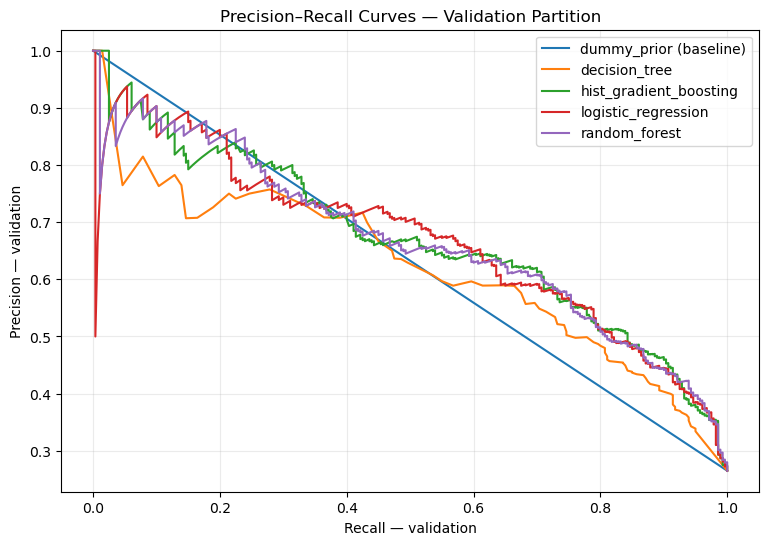

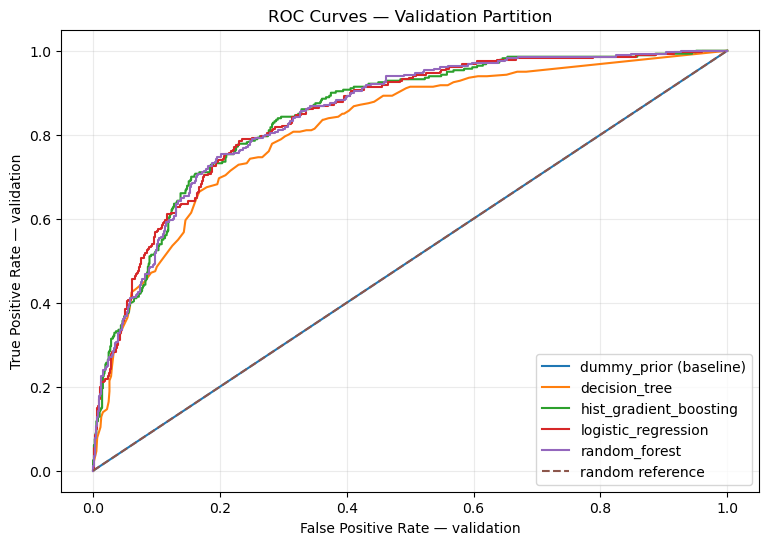

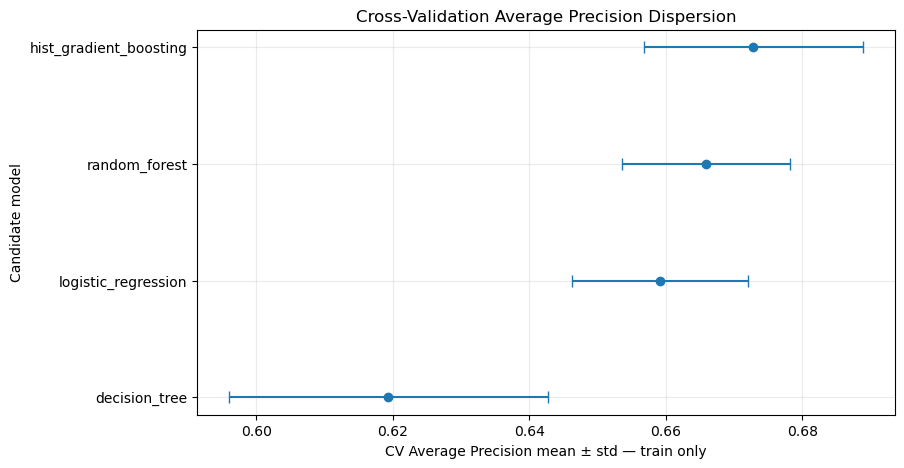

In [15]:
ALL_VALIDATION_EVALUATIONS = {
    BASELINE_SPEC['model_id']: DUMMY_EVALUATION,
    **VALIDATION_EVALUATIONS,
}

plt.figure(figsize=(9, 6))
for model_id, evaluation in ALL_VALIDATION_EVALUATIONS.items():
    curve = evaluation['precision_recall_curve']
    label = f"{model_id} (baseline)" if model_id == BASELINE_SPEC['model_id'] else model_id
    plt.plot(curve['recall'], curve['precision'], label=label)
plt.xlabel('Recall — validation')
plt.ylabel('Precision — validation')
plt.title('Precision–Recall Curves — Validation Partition')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(9, 6))
for model_id, evaluation in ALL_VALIDATION_EVALUATIONS.items():
    curve = evaluation['roc_curve']
    label = f"{model_id} (baseline)" if model_id == BASELINE_SPEC['model_id'] else model_id
    plt.plot(curve['false_positive_rate'], curve['true_positive_rate'], label=label)
plt.plot([0, 1], [0, 1], linestyle='--', label='random reference')
plt.xlabel('False Positive Rate — validation')
plt.ylabel('True Positive Rate — validation')
plt.title('ROC Curves — Validation Partition')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(9, 5))
ordered = cv_summary_table.sort_values('cv_average_precision_mean')
plt.errorbar(
    ordered['cv_average_precision_mean'],
    ordered['model_id'],
    xerr=ordered['cv_average_precision_std'],
    fmt='o',
    capsize=4,
)
plt.xlabel('CV Average Precision mean ± std — train only')
plt.ylabel('Candidate model')
plt.title('Cross-Validation Average Precision Dispersion')
plt.grid(alpha=0.25)
plt.show()

The curves confirm the central ranking without changing the predeclared metrics, models, spaces, or partition roles. CV dispersion is considered alongside external validation performance rather than replacing it.

## 16. Finalist Confusion and Calibration Diagnostics

Confusion matrices and calibration curves are shown separately for the two validation finalists at threshold 0.50.

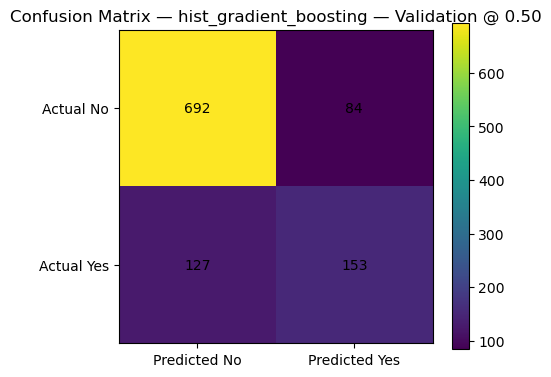

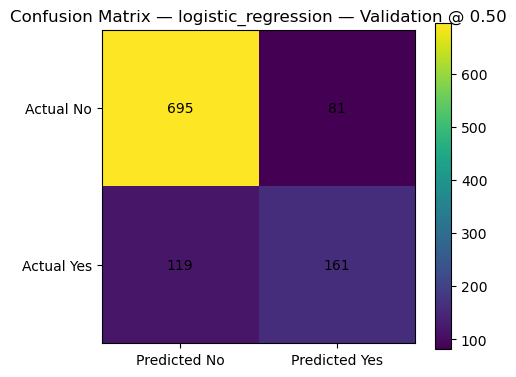

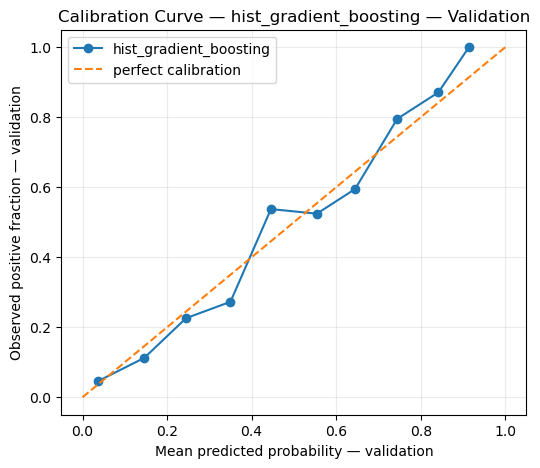

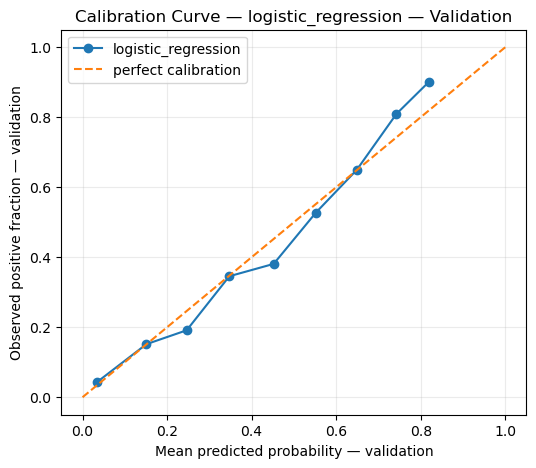

In [16]:
for model_id in FINALIST_IDS:
    metrics = VALIDATION_EVALUATIONS[model_id]['metrics']
    matrix = [
        [metrics['true_negatives'], metrics['false_positives']],
        [metrics['false_negatives'], metrics['true_positives']],
    ]
    figure, axis = plt.subplots(figsize=(5, 4))
    image = axis.imshow(matrix)
    for row in range(2):
        for column in range(2):
            axis.text(column, row, matrix[row][column], ha='center', va='center')
    axis.set_xticks([0, 1], labels=['Predicted No', 'Predicted Yes'])
    axis.set_yticks([0, 1], labels=['Actual No', 'Actual Yes'])
    axis.set_title(f'Confusion Matrix — {model_id} — Validation @ 0.50')
    figure.colorbar(image, ax=axis)
    plt.tight_layout()
    plt.show()

for model_id in FINALIST_IDS:
    calibration = VALIDATION_EVALUATIONS[model_id]['calibration_curve']
    plt.figure(figsize=(6, 5))
    plt.plot(
        calibration['mean_predicted_probability'],
        calibration['fraction_of_positives'],
        marker='o',
        label=model_id,
    )
    plt.plot([0, 1], [0, 1], linestyle='--', label='perfect calibration')
    plt.xlabel('Mean predicted probability — validation')
    plt.ylabel('Observed positive fraction — validation')
    plt.title(f'Calibration Curve — {model_id} — Validation')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

False negatives receive educational attention because a missed churner removes a possible retention opportunity. However, no financial cost ratio or campaign policy is inferred from these diagnostics.

## 17. Educational Threshold Analysis

Threshold analysis is performed only for the selected family and only on `validation`. The selected scenario maximizes precision subject to recall ≥ 0.80, then breaks ties by F2 and the highest threshold. The result remains explicitly non-operational.

,scenario_id,threshold,precision,recall,f1,f2,true_positives,false_positives,true_negatives,false_negatives,predicted_positive_count,predicted_positive_rate,recall_target,target_satisfied,selection_rule
0,default_0_50,0.500000,0.645570,0.546429,0.591876,0.563744,153,84,692,127,237,0.224432,NaN,None,fixed_threshold_0_50
1,maximum_f1,0.403424,0.620253,0.700000,0.657718,0.682451,196,120,656,84,316,0.299242,NaN,None,maximize_f1_then_precision_recall_threshold
2,maximum_f2,0.177194,0.464088,0.900000,0.612394,0.757667,252,291,485,28,543,0.514205,NaN,None,maximize_f2_then_precision_recall_threshold
3,minimum_recall_0_70,0.403424,0.620253,0.700000,0.657718,0.682451,196,120,656,84,316,0.299242,0.7,True,maximize_precision_subject_to_minimum_recall_t...
4,minimum_recall_0_80,0.257781,0.513575,0.810714,0.628809,0.726633,227,215,561,53,442,0.418561,0.8,True,maximize_precision_subject_to_minimum_recall_t...
5,minimum_recall_0_90,0.177194,0.464088,0.900000,0.612394,0.757667,252,291,485,28,543,0.514205,0.9,True,maximize_precision_subject_to_minimum_recall_t...


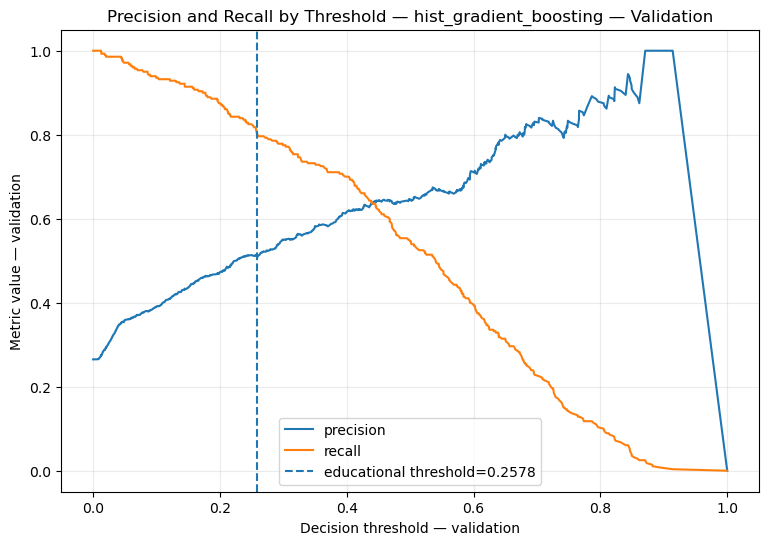

In [17]:
THRESHOLD_ANALYSIS = analyze_thresholds(
    y_validation=y_validation,
    positive_probabilities=VALIDATION_EVALUATIONS[SELECTED_MODEL_ID]['positive_probabilities'],
    recall_targets=(0.70, 0.80, 0.90),
    selected_scenario_id='minimum_recall_0_80',
)
SELECTED_THRESHOLD_SCENARIO = THRESHOLD_ANALYSIS['selected_scenario']
SELECTED_EDUCATIONAL_THRESHOLD = THRESHOLD_ANALYSIS['selected_educational_threshold']

threshold_scenarios_table = pd.DataFrame(THRESHOLD_ANALYSIS['scenarios'])[
    [
        'scenario_id', 'threshold', 'precision', 'recall', 'f1', 'f2',
        'true_positives', 'false_positives', 'true_negatives', 'false_negatives',
        'predicted_positive_count', 'predicted_positive_rate',
        'recall_target', 'target_satisfied', 'selection_rule',
    ]
]
display(threshold_scenarios_table)

threshold_grid = THRESHOLD_ANALYSIS['threshold_grid']
plt.figure(figsize=(9, 6))
plt.plot(threshold_grid['thresholds'], threshold_grid['precision'], label='precision')
plt.plot(threshold_grid['thresholds'], threshold_grid['recall'], label='recall')
plt.axvline(
    SELECTED_EDUCATIONAL_THRESHOLD,
    linestyle='--',
    label=f'educational threshold={SELECTED_EDUCATIONAL_THRESHOLD:.4f}',
)
plt.xlabel('Decision threshold — validation')
plt.ylabel('Metric value — validation')
plt.title(f'Precision and Recall by Threshold — {SELECTED_MODEL_ID} — Validation')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 18. Model-Selection Findings

The selected family is a candidate for final training in notebook 04, not a trained final model. Selection evidence is educational and limited to the stratified random snapshot contract.

In [18]:
findings = {
    'selected_model_id': SELECTED_MODEL_ID,
    'selected_model_family': SELECTED_MODEL_FAMILY,
    'best_hyperparameters': SELECTED_OUTCOME.best_parameters,
    'validation_average_precision': VALIDATION_EVALUATIONS[SELECTED_MODEL_ID]['metrics']['average_precision'],
    'validation_roc_auc': VALIDATION_EVALUATIONS[SELECTED_MODEL_ID]['metrics']['roc_auc'],
    'educational_threshold_scenario': SELECTED_THRESHOLD_SCENARIO['scenario_id'],
    'educational_threshold': SELECTED_EDUCATIONAL_THRESHOLD,
    'educational_threshold_recall': SELECTED_THRESHOLD_SCENARIO['recall'],
    'operational_validity': 'unconfirmed',
    'operational_threshold': 'unresolved',
    'test_partition_evaluated': False,
}
print(json.dumps(findings, indent=2, sort_keys=True))

{
  "best_hyperparameters": {
    "model__l2_regularization": 1.0,
    "model__learning_rate": 0.03,
    "model__max_depth": 3,
    "model__max_iter": 200,
    "model__max_leaf_nodes": 7,
    "model__min_samples_leaf": 40
  },
  "educational_threshold": 0.2577809673219062,
  "educational_threshold_recall": 0.8107142857142857,
  "educational_threshold_scenario": "minimum_recall_0_80",
  "operational_threshold": "unresolved",
  "operational_validity": "unconfirmed",
  "selected_model_family": "HistGradientBoostingClassifier",
  "selected_model_id": "hist_gradient_boosting",
  "test_partition_evaluated": false,
  "validation_average_precision": 0.67082102305192,
  "validation_roc_auc": 0.8477494477172314
}


## 19. Artifact Materialization

Six runtime artifacts are written as one atomic set under `artifacts/model-selection/<dataset>/`. Existing semantically equivalent artifacts are accepted idempotently; divergent artifacts fail unless overwrite is explicitly requested. This notebook never requests overwrite.

In [19]:
def canonical_contract_fingerprint(payload):
    return semantic_fingerprint_json(payload)

PREPARATION_REFERENCES = {
    f'{name}_path': path.as_posix()
    for name, path in PREPARATION_PATHS.items()
}
PREPARATION_FINGERPRINTS = {
    f'{name}_sha256': sha256_file(PROJECT_ROOT / path)
    for name, path in PREPARATION_PATHS.items()
}
PREPARATION_FINGERPRINTS.update({
    'prepared_dataset_sha256': preparation_manifests['preparation_manifest']['prepared_sha256'],
    'train_sha256': preparation_manifests['split_manifest']['partition_sha256']['train'],
    'validation_sha256': preparation_manifests['split_manifest']['partition_sha256']['validation'],
    'test_sha256_integrity_reference_only': preparation_manifests['split_manifest']['partition_sha256']['test'],
    'feature_contract_fingerprint': canonical_contract_fingerprint({
        key: feature_manifest[key]
        for key in [
            'identifier_columns', 'feature_columns', 'numerical_features',
            'categorical_features', 'target_column', 'target_classes',
            'positive_target_class', 'target_encoding_contract',
            'preprocessing_contract', 'prohibited_predictors',
        ]
    }),
    'preparation_contract_fingerprint': canonical_contract_fingerprint({
        key: preparation_manifests['preparation_manifest'][key]
        for key in [
            'dataset_slug', 'contract_version', 'prepared_sha256',
            'source_row_count', 'prepared_row_count', 'source_column_count',
            'prepared_column_count', 'column_order', 'deterministic_rules',
            'materialized_value_counts', 'invalid_conversion_counts',
            'row_preservation_checks', 'raw_immutability_checks', 'readiness',
        ]
    }),
})

READINESS = {
    'educational_model_selection_completed': True,
    'educational_final_candidate_selected': True,
    'educational_threshold_selected': True,
    'model_selection_handoff_ready': True,
    'final_model_training_ready': True,
    'test_partition_sealed': True,
    'test_partition_evaluated': False,
    'final_model_trained': False,
    'model_artifact_materialized': False,
    'model_bundle_materialized': False,
    'operational_modeling_ready': False,
    'operational_validity': 'unconfirmed',
    'temporal_contract_status': 'unresolved',
    'feature_inference_availability': 'unconfirmed',
    'operational_threshold': 'unresolved',
}

ARTIFACT_PATHS = {
    filename: (MODEL_SELECTION_ROOT / filename).as_posix()
    for filename in ARTIFACT_FILENAMES
}
SEARCH_STRATEGIES = {
    spec['model_id']: spec['search_strategy']
    for spec in CANDIDATE_SPECS
}
SEARCH_SPACES = {
    spec['model_id']: spec['search_space']
    for spec in CANDIDATE_SPECS
}
RANDOM_SEEDS = {
    'split_reference': preparation_manifests['split_manifest']['random_seed'],
    'cross_validation': RANDOM_SEED,
    'randomized_search': RANDOM_SEED,
    'estimators': RANDOM_SEED,
}

MODEL_SELECTION_MANIFEST = build_model_selection_manifest(
    dataset_slug=DATASET_SLUG,
    preparation_references=PREPARATION_REFERENCES,
    preparation_fingerprints=PREPARATION_FINGERPRINTS,
    model_selection_contract=MODEL_SELECTION_CONTRACT,
    candidate_model_ids=[spec['model_id'] for spec in CANDIDATE_SPECS],
    baseline_model_id=BASELINE_SPEC['model_id'],
    cv_contract={
        **MODEL_SELECTION_CONTRACT['cv'],
        'fold_class_distributions': CV_FOLD_DISTRIBUTIONS,
        'n_jobs': SEARCH_N_JOBS,
    },
    scoring_contract=SCORING_METADATA,
    search_strategies=SEARCH_STRATEGIES,
    search_spaces=SEARCH_SPACES,
    random_seeds=RANDOM_SEEDS,
    artifact_paths=ARTIFACT_PATHS,
    readiness=READINESS,
    limitations=[
        'Educational stratified-random snapshot benchmark only.',
        'Future-customer and temporal validity are unconfirmed.',
        'Feature availability at inference time is unconfirmed.',
        'Business error costs and an operational threshold are unresolved.',
        'The final model is not trained and test is not evaluated in notebook 03.',
    ],
)

BASELINE_RECORD = {
    'model_id': BASELINE_SPEC['model_id'],
    'family': BASELINE_SPEC['family'],
    'strategy': 'prior',
    'eligible': False,
    'validation_metrics_at_0_50': DUMMY_EVALUATION['metrics'],
    'unknown_categories_report': DUMMY_UNKNOWN_CATEGORIES,
    'failures': [],
    'warnings': [],
}
CANDIDATE_RESULTS = build_candidate_results(
    baseline=BASELINE_RECORD,
    candidate_summaries=[CV_SUMMARIES[spec['model_id']] for spec in CANDIDATE_SPECS],
    validation_evaluations=VALIDATION_EVALUATIONS,
    selection=SELECTION,
    warnings_by_model=WARNINGS_BY_MODEL,
)
VALIDATION_EVIDENCE = build_validation_evidence(
    dataset_slug=DATASET_SLUG,
    evaluations=VALIDATION_EVALUATIONS,
    dummy_evaluation=DUMMY_EVALUATION,
    unknown_categories=UNKNOWN_CATEGORIES,
    selection=SELECTION,
    threshold=DEFAULT_THRESHOLD,
)
THRESHOLD_ARTIFACT = build_threshold_analysis(
    dataset_slug=DATASET_SLUG,
    selected_model_id=SELECTED_MODEL_ID,
    analysis=THRESHOLD_ANALYSIS,
    educational_recall_target=EDUCATIONAL_RECALL_TARGET,
)
MODEL_SELECTION_HANDOFF = build_model_selection_handoff(
    dataset_slug=DATASET_SLUG,
    preparation_contract_references={
        **PREPARATION_REFERENCES,
        **PREPARATION_FINGERPRINTS,
    },
    selected_model_family=SELECTED_MODEL_FAMILY,
    selected_model_id=SELECTED_MODEL_ID,
    selected_hyperparameters=SELECTED_OUTCOME.best_parameters,
    selected_preprocessing_contract={
        **feature_manifest['preprocessing_contract'],
        'numerical_scaling_for_selected_family': (
            'standard_scaler' if SELECTED_MODEL_ID == 'logistic_regression' else 'none'
        ),
    },
    selected_validation_metrics=VALIDATION_EVALUATIONS[SELECTED_MODEL_ID]['metrics'],
    selected_educational_threshold=SELECTED_THRESHOLD_SCENARIO,
    threshold_selection_rule=SELECTED_THRESHOLD_SCENARIO['selection_rule'],
    selection_rationale=SELECTION['selection_rationale'],
    feature_columns=FEATURE_COLUMNS,
    numerical_features=NUMERICAL_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    target_encoding=TARGET_ENCODING,
    positive_class=POSITIVE_TARGET_CLASS,
    random_seeds=RANDOM_SEEDS,
    final_training_instructions={
        'notebook': 'notebooks/04_final_model_and_bundle.ipynb',
        'reconstruct_pipeline_from_contract': True,
        'fit_partitions': ['train', 'validation'],
        'final_evaluation_partition': 'test',
        'evaluate_test_once': True,
        'reuse_selected_hyperparameters': True,
        'freeze_educational_threshold_before_test_access': True,
        'do_not_retune_on_test': True,
    },
    readiness=READINESS,
)

ARTIFACT_PAYLOADS = {
    'model-selection-manifest.json': MODEL_SELECTION_MANIFEST,
    'candidate-results.json': CANDIDATE_RESULTS,
    'cross-validation-results.csv': CROSS_VALIDATION_RESULTS,
    'validation-evidence.json': VALIDATION_EVIDENCE,
    'threshold-analysis.json': THRESHOLD_ARTIFACT,
    'model-selection-handoff.json': MODEL_SELECTION_HANDOFF,
}

WRITE_RESULT = write_model_selection_artifacts(
    output_directory=PROJECT_ROOT / MODEL_SELECTION_ROOT,
    artifacts=ARTIFACT_PAYLOADS,
    overwrite=False,
)
print('Artifact materialization:', {
    'created': list(WRITE_RESULT.created),
    'replaced': list(WRITE_RESULT.replaced),
    'idempotent': WRITE_RESULT.idempotent,
})
for filename in ARTIFACT_FILENAMES:
    print(f"  {ARTIFACT_PATHS[filename]} sha256={WRITE_RESULT.byte_sha256[filename]}")

Artifact materialization: {'created': [], 'replaced': [], 'idempotent': True}
  artifacts/model-selection/telco-customer-churn/model-selection-manifest.json sha256=52fbae1a5a7ac2e8a1759cba1cfb5b7510f185d63b51f0e28af6ad7f39f5dc94
  artifacts/model-selection/telco-customer-churn/candidate-results.json sha256=0de96246913c3de3933defaa22937d77420bac1f6c1d698820cdc802eb84a038
  artifacts/model-selection/telco-customer-churn/cross-validation-results.csv sha256=34162fb7cc820a936eb81b02e2fee7e02fff472fe27580370dae4a81198fa07c
  artifacts/model-selection/telco-customer-churn/validation-evidence.json sha256=e7aede15e95f02fd89047b29b617dec088a8f75d9d34dcdc81b8cdfbc5adcbe8
  artifacts/model-selection/telco-customer-churn/threshold-analysis.json sha256=ee5d286eb067e1f90c7ec0c604b014027015f26303fca2b9b029a7ea8b406b5c
  artifacts/model-selection/telco-customer-churn/model-selection-handoff.json sha256=f8f43429cc74d5026261a908b6e1e3fe7e53c1aaacebf704d85553b561ccdad4


## 20. Final-Model Handoff

The persisted handoff is loaded back and revalidated, including sibling artifact fingerprints. Notebook 04 may reconstruct the selected pipeline, fit the final model on `train + validation`, and evaluate `test` exactly once. No model, pipeline, scaler, encoder, bundle, or test prediction is materialized here.

In [20]:
RELOADED_HANDOFF = load_and_validate_model_selection_handoff(
    project_root=PROJECT_ROOT,
    handoff_path=MODEL_SELECTION_ROOT / 'model-selection-handoff.json',
)

assert RELOADED_HANDOFF['selected_model_id'] == SELECTED_MODEL_ID
assert RELOADED_HANDOFF['test_partition_sealed'] is True
assert RELOADED_HANDOFF['test_partition_evaluated'] is False
assert RELOADED_HANDOFF['final_model_trained'] is False
assert RELOADED_HANDOFF['model_artifact'] is None
assert RELOADED_HANDOFF['model_bundle_materialized'] is False
assert RELOADED_HANDOFF['operational_validity'] == 'unconfirmed'
assert RELOADED_HANDOFF['operational_threshold'] == 'unresolved'

final_report = {
    'handoff_path': (MODEL_SELECTION_ROOT / 'model-selection-handoff.json').as_posix(),
    'selected_model_id': RELOADED_HANDOFF['selected_model_id'],
    'selected_model_family': RELOADED_HANDOFF['selected_model_family'],
    'educational_threshold': RELOADED_HANDOFF['selected_educational_threshold']['threshold'],
    'test_partition_sealed': RELOADED_HANDOFF['test_partition_sealed'],
    'test_partition_evaluated': RELOADED_HANDOFF['test_partition_evaluated'],
    'final_model_trained': RELOADED_HANDOFF['final_model_trained'],
    'model_artifact_materialized': RELOADED_HANDOFF['model_artifact_materialized'],
    'model_bundle_materialized': RELOADED_HANDOFF['model_bundle_materialized'],
    'operational_validity': RELOADED_HANDOFF['operational_validity'],
    'operational_threshold': RELOADED_HANDOFF['operational_threshold'],
}
print(json.dumps(final_report, indent=2, sort_keys=True))

{
  "educational_threshold": 0.2577809673219062,
  "final_model_trained": false,
  "handoff_path": "artifacts/model-selection/telco-customer-churn/model-selection-handoff.json",
  "model_artifact_materialized": false,
  "model_bundle_materialized": false,
  "operational_threshold": "unresolved",
  "operational_validity": "unconfirmed",
  "selected_model_family": "HistGradientBoostingClassifier",
  "selected_model_id": "hist_gradient_boosting",
  "test_partition_evaluated": false,
  "test_partition_sealed": true
}


**Conclusion.** Educational model selection is complete only because the preparation handoff passed, all four required searches completed, an eligible family exceeded the Dummy margin, the selected threshold was fixed from validation, the six runtime artifacts were atomically materialized and revalidated, and the test partition remained sealed. Operational validity remains unconfirmed.